In [12]:
import sys
sys.path.insert(0, "../../../")

import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

from agnpy.emission_regions import Blob
from agnpy.targets import RingDustTorus
from agnpy.spectra import ExpCutoffPowerLaw

from astropy.constants import m_p, h
from agnpy.utils.conversion import mec2, mpc2
from agnpy.utils.math import axes_reshaper, log10
from agnpy.photo_meson.kernels import eta_0, secondaries, interpolate_g_parameter, gKernel
from agnpy.photo_meson.photo_meson import PhotoMesonProductionAngular

# import pandas as pd

In [13]:
L_disk = 2 * 1e45 * u.Unit("erg s-1") # up to 1e48 erg / s
T_dt = 1200 * u.K # up to 1500 K
xi_dt = 0.1

dust_torus = RingDustTorus(L_disk, xi_dt, T_dt)

print("u = ",dust_torus.u(0.*u.Unit("cm")))
print("epsilion = ", (dust_torus.epsilon_dt*mec2).to("eV"))
print(dust_torus.R_dt)

u =  5.592111521397121e-05 erg / cm3
epsilion =  0.2792015976935039 eV
3.081142627401995e+18 cm


In [14]:
factor = 1e0
E_star = 1e19 * u.Unit("eV")
gamma_star = (E_star / mpc2).to_value("")

Gamma = 10 # standardowo 10 lub 30; do 100
theta_s = 0*u.deg
R_b = 1e16*u.Unit("cm")

blob = Blob(R_b=R_b)
blob.set_delta_D(Gamma=Gamma, theta_s=theta_s)

delta_D = blob.delta_D

n_p = ExpCutoffPowerLaw.from_total_energy_density(
    1.0 * u.Unit("erg/cm3"),
    mass = m_p,
    p = 2,
    gamma_c = factor * gamma_star / delta_D,
    gamma_min = (1.0e-5 * u.Unit("eV") / (mpc2 * delta_D)).to_value(""),
    gamma_max = 30.0 * factor * gamma_star / delta_D
)

blob.n_p = n_p

print(delta_D)
print(blob.theta_s)

19.94987437106624
0.0 deg


/home/piotr/Dokumenty/CODE/agnpy_cosimo/.venv/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/piotr/Dokumenty/CODE/agnpy_cosimo/.venv/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/piotr/Dokumenty/CODE/agnpy_cosimo/.venv/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/piotr/Dokumenty/CODE/agnpy_cosimo/.venv/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Text(0, 0.5, '$\\nu\\;F_\\nu$  [erg cm$^{-2}$ s$^{-1}$]')

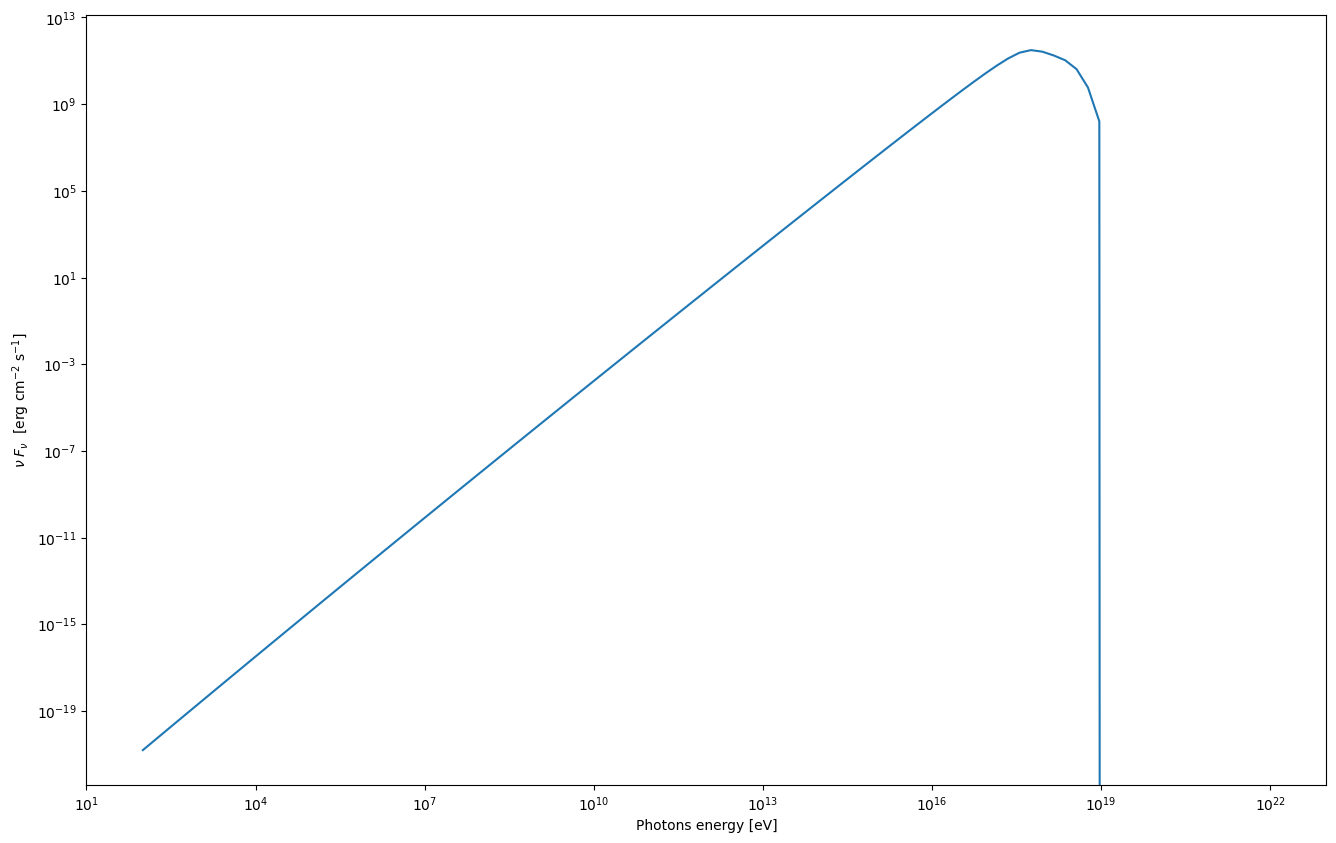

In [15]:
E = np.logspace(2, 22, 100) * u.Unit("eV")
r = 0*u.Unit("cm")


fig, ax = plt.subplots(1, 1, figsize = (16, 10))

kernel = PhotoMesonProductionAngular(blob=blob,target=dust_torus)

X = E.to_value("eV")

XX = (E/h).to_value("Hz")

Y = kernel.evaluate_spectrum(E,r,"gamma")
Y.to_value("erg-1 cm-3")

# ax.set_ylim(1e-25,1e-5)

d_L = 1e27 # cm

ax.loglog(X,X**2 * Y / d_L**2)

ax.set_xlabel("Photons energy [eV]")
ax.set_ylabel(r"$\nu\;F_\nu$  [erg cm$^{-2}$ s$^{-1}$]")

In [16]:
# # import sys
# # !{sys.executable} -m pip install "regions<0.10"

# from gammapy.estimators import FluxPoints
# from regions._utils.wcs_helpers import pixel_scale_angle_at_skycoord 

In [17]:
# # Load MAGIC/LST flux points
# magic_lst_flux_points = FluxPoints.read("./target/data_products/MAGIC_LST_flux_points.ecsv")
# magic_lst_table = magic_lst_flux_points.to_table(sed_type="e2dnde")
# magic_lst_energy = magic_lst_flux_points.energy_ref

# magic_lst_nu = magic_lst_energy.to(u.eV, equivalencies=u.spectral())
# magic_lst_sed = magic_lst_table["e2dnde"].quantity.to(u.erg*u.cm**-2*u.s**-1)
# magic_lst_sed_err = magic_lst_table["e2dnde_err"].quantity.to(u.erg*u.cm**-2*u.s**-1)
# magic_lst_sed_ul = magic_lst_table["e2dnde_ul"].quantity.to(u.erg*u.cm**-2*u.s**-1)

# # Load Fermi SED sim to MAGIC/LST
# # strictly sim
# fermi_SED_strictly_sim = pd.read_csv("./target/data_products/fermi_SED_points_strictly_sim.txt", sep=r"\s+", header=None)

# E_center_fermi_strictly_sim = fermi_SED_strictly_sim[1].values*u.GeV 
# e2dnde_center_fermi_strictly_sim = fermi_SED_strictly_sim[4].values*u.erg*u.cm**-2*u.s**-1
# e2dnde_err_fermi_strictly_sim = fermi_SED_strictly_sim[3].values*u.erg*u.cm**-2*u.s**-1

# ##
# fermi_SED = pd.read_csv("./target/data_products/fermi_SED_points.txt", sep=r"\s+", header=None)

# E_center_fermi = fermi_SED[1].values*u.GeV 
# e2dnde_center_fermi = fermi_SED[4].values*u.erg*u.cm**-2*u.s**-1
# e2dnde_err_fermi = fermi_SED[3].values*u.erg*u.cm**-2*u.s**-1

# fig, ax = plt.subplots(figsize=(8, 6))

# # Plot data

# plt.errorbar(magic_lst_nu[~magic_lst_table["is_ul"]], magic_lst_sed[~magic_lst_table["is_ul"]], 
# 		 yerr=magic_lst_sed_err[~magic_lst_table["is_ul"]],
# 		 color='C3', fmt="o", label='MAGIC/LST-1')
# plt.errorbar(magic_lst_nu[magic_lst_table["is_ul"]], magic_lst_sed_ul[magic_lst_table["is_ul"]], 
# 		 color='C3', fmt="v")

# plt.errorbar(E_center_fermi[e2dnde_err_fermi>0].to(u.eV, equivalencies=u.spectral()), 
# 			 e2dnde_center_fermi[e2dnde_err_fermi>0], yerr=e2dnde_err_fermi[e2dnde_err_fermi>0],
# 			 fmt='o', color='C4', label=r'Fermi-LAT')
# plt.errorbar(E_center_fermi[e2dnde_err_fermi==0].to(u.eV, equivalencies=u.spectral()), 
# 			 e2dnde_center_fermi[e2dnde_err_fermi==0], yerr=e2dnde_err_fermi[e2dnde_err_fermi==0],
# 			 fmt='v', color='C4')
# plt.errorbar(E_center_fermi_strictly_sim[e2dnde_err_fermi_strictly_sim>0].to(u.eV, equivalencies=u.spectral()), 
# 			 e2dnde_center_fermi_strictly_sim[e2dnde_err_fermi_strictly_sim>0], yerr=e2dnde_err_fermi_strictly_sim[e2dnde_err_fermi_strictly_sim>0],
# 			 fmt='o', color='C4', alpha=0.5)
# plt.errorbar(E_center_fermi_strictly_sim[e2dnde_err_fermi_strictly_sim==0].to(u.eV, equivalencies=u.spectral()), 
# 			 e2dnde_center_fermi_strictly_sim[e2dnde_err_fermi_strictly_sim==0], yerr=e2dnde_err_fermi_strictly_sim[e2dnde_err_fermi_strictly_sim==0],
# 			 fmt='v', color='C4', alpha=0.5)

# plt.xlabel(r'eV', fontsize=18)
# plt.ylabel(r'$\nu F_{\nu}$ [erg/cm$^{2}$/s]', fontsize=18)
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)


# L_disk = 1e44 * u.Unit("erg s-1") # up to 1e48 erg / s
# T_dt = 1500 * u.K # up to 1500 K
# xi_dt = 0.1

# dust_torus = RingDustTorus(L_disk, xi_dt, T_dt)

# factor = 1e0
# E_star = 1e19 * u.Unit("eV")
# gamma_star = (E_star / mpc2).to_value("")

# Gamma = 10 # standardowo 10 lub 30; do 100
# theta_s = 2.7*u.deg
# R_b = 1e16*u.Unit("cm")

# blob = Blob(R_b=R_b)
# blob.set_delta_D(Gamma=Gamma, theta_s=theta_s)

# delta_D = blob.delta_D

# n_p = ExpCutoffPowerLaw.from_total_energy_density(
#     1.0e-4 * u.Unit("erg/cm3"),
#     mass = m_p,
#     p = 2,
#     gamma_c = factor * gamma_star / delta_D,
#     gamma_min = (1.0 * u.Unit("MeV") / (mpc2 * delta_D)).to_value(""),
#     gamma_max = 30.0 * factor * gamma_star / delta_D
# )

# blob.n_p = n_p


# kernel = PhotoMesonProductionAngular(blob=blob,target=dust_torus)

# X = E.to_value("erg")

# # XX = (E/h).to_value("Hz")
# XX = E.to_value("eV")

# Y = kernel.evaluate_spectrum(E,r,"gamma")
# Y.to_value("erg-1 cm-3")

# # ax.set_ylim(1e-25,1e-5)

# d_L = 1e24 # cm

# plt.plot(XX,X**2 * Y / d_L**2,label="Fit")

# plt.legend(loc='upper left',frameon=False, ncol=3, fontsize=11)
# plt.loglog()

# # ax.set_xlim(1e5, 1e15)
# ax.set_ylim(1e-15, 4e-10)
# plt.show()